In [ ]:
# first import this

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
#then load the file 

In [4]:
df = pd.read_csv("D:\Downloads\ecommerce_ab_testing.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 50000
Columns: 15


In [5]:
df.head()

,user_id,experiment_group,date,device,country,user_type,traffic_source,sessions,session_duration_sec,product_views,add_to_cart,checkout_started,purchased,order_value,revenue_per_user
0,U00001,Treatment,23-08-2026 00:00,Tablet,India,New,Organic,1,200,4,0,0,0,0,0
1,U00002,Control,28-08-2026 00:00,Mobile,USA,Returning,Organic,2,252,11,0,0,0,0,0
2,U00003,Treatment,18-08-2026 00:00,Tablet,USA,New,Organic,2,80,6,0,0,0,0,0
3,U00004,Treatment,13-08-2026 00:00,Desktop,USA,Returning,Organic,1,142,3,0,0,0,0,0
4,U00005,Control,01-08-2026 00:00,Desktop,Canada,Returning,Email,2,244,7,0,0,0,0,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   user_id               50000 non-null  str  
 1   experiment_group      50000 non-null  str  
 2   date                  50000 non-null  str  
 3   device                50000 non-null  str  
 4   country               50000 non-null  str  
 5   user_type             50000 non-null  str  
 6   traffic_source        50000 non-null  str  
 7   sessions              50000 non-null  int64
 8   session_duration_sec  50000 non-null  int64
 9   product_views         50000 non-null  int64
 10  add_to_cart           50000 non-null  int64
 11  checkout_started      50000 non-null  int64
 12  purchased             50000 non-null  int64
 13  order_value           50000 non-null  int64
 14  revenue_per_user      50000 non-null  int64
dtypes: int64(8), str(7)
memory usage: 8.3 MB


In [ ]:
 #finding missing value

In [8]:
print("missing")
print(df.isnull().sum())

missing
user_id                 0
experiment_group        0
date                    0
device                  0
country                 0
user_type               0
traffic_source          0
sessions                0
session_duration_sec    0
product_views           0
add_to_cart             0
checkout_started        0
purchased               0
order_value             0
revenue_per_user        0
dtype: int64


In [11]:
print("duplicate value")
print(df.duplicated().sum)
print("duplicate user id",df["user_id"].duplicated().sum)

print("\nExperiment groups:")
print(df["experiment_group"].value_counts())

duplicate value
<bound method Series.sum of 0        False
1        False
2        False
3        False
4        False
         ...  
49995    False
49996    False
49997    False
49998    False
49999    False
Length: 50000, dtype: bool>
duplicate user id <bound method Series.sum of 0        False
1        False
2        False
3        False
4        False
         ...  
49995    False
49996    False
49997    False
49998    False
49999    False
Name: user_id, Length: 50000, dtype: bool>

Experiment groups:
experiment_group
Treatment    25186
Control      24814
Name: count, dtype: int64


## Step 5 — Separate Control and Treatment

In [12]:
#Step 5 — Separate Control and Treatment

control = df[df["experiment_group"] == "Control"]
treatment = df[df["experiment_group"] == "Treatment"]

print("Control users:", len(control))
print("Treatment users:", len(treatment))

Control users: 24814
Treatment users: 25186


In [13]:
#Step 6 — Calculate conversion rates
control_users = len(control)
treatment_users = len(treatment)

control_purchases = control["purchased"].sum()
treatment_purchases = treatment["purchased"].sum()

control_conversion = control_purchases / control_users
treatment_conversion = treatment_purchases / treatment_users

print("Control Conversion Rate:", control_conversion)
print("Treatment Conversion Rate:", treatment_conversion)

Control Conversion Rate: 0.07793987265253485
Treatment Conversion Rate: 0.08028269673628206


In [14]:
#Step 7 — Calculate uplift


absolute_difference = treatment_conversion - control_conversion

relative_uplift = (
    (treatment_conversion - control_conversion)
    / control_conversion
)

print(f"Absolute Difference: {absolute_difference:.4%}")
print(f"Relative Uplift: {relative_uplift:.2%}")

Absolute Difference: 0.2343%
Relative Uplift: 3.01%


In [15]:
#Step 8 — Two-Proportion Z-Test


# Number of users and purchases
n_control = control_users
n_treatment = treatment_users

x_control = control_purchases
x_treatment = treatment_purchases

# Conversion rates
p_control = x_control / n_control
p_treatment = x_treatment / n_treatment

# Pooled conversion rate
p_pooled = (x_control + x_treatment) / (n_control + n_treatment)

# Standard error
standard_error = np.sqrt(
    p_pooled * (1 - p_pooled) *
    (1/n_control + 1/n_treatment)
)

# Z-score
z_score = (p_treatment - p_control) / standard_error

print(f"Pooled Conversion Rate: {p_pooled:.4%}")
print(f"Standard Error: {standard_error:.6f}")
print(f"Z-score: {z_score:.4f}")

Pooled Conversion Rate: 7.9120%
Standard Error: 0.002414
Z-score: 0.9704


In [16]:
#Step 9 — Calculate P-value



p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

print(f"P-value: {p_value:.4f}")
print(f"P-value: {p_value:.2%}")

P-value: 0.3319
P-value: 33.19%


In [ ]:
#Step 10 — Statistical decision



alpha = 0.05

if p_value < alpha:
    result = "Statistically Significant"
else:
    result = "Not Statistically Significant"

print("Result:", result)

In [17]:
# Step 11 — 95% Confidence Interval


# Standard error for confidence interval
ci_standard_error = np.sqrt(
    (p_control * (1 - p_control) / n_control) +
    (p_treatment * (1 - p_treatment) / n_treatment)
)

# Difference
difference = p_treatment - p_control

# 95% confidence interval
ci_lower = difference - 1.96 * ci_standard_error
ci_upper = difference + 1.96 * ci_standard_error

print(f"Difference: {difference:.4%}")
print(f"95% CI Lower: {ci_lower:.4%}")
print(f"95% CI Upper: {ci_upper:.4%}")

Difference: 0.2343%
95% CI Lower: -0.2389%
95% CI Upper: 0.7074%


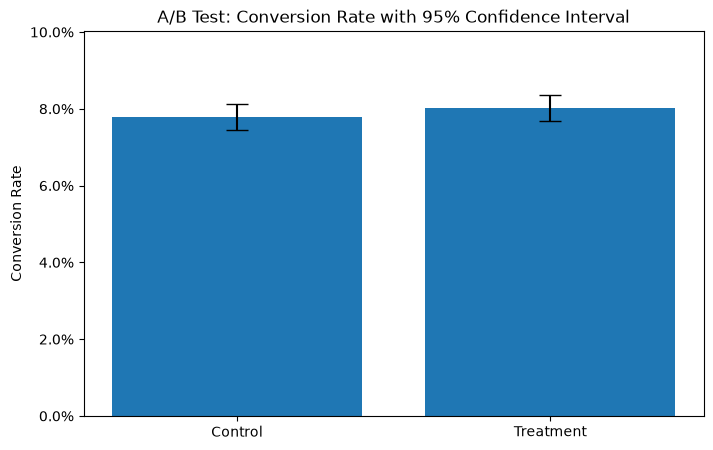

In [18]:
#Step 12 — Conversion Rate with 95% Confidence Interval


# Conversion rates
groups = ["Control", "Treatment"]
conversion_rates = [p_control, p_treatment]

# Calculate confidence intervals for each group
control_se = np.sqrt(p_control * (1 - p_control) / n_control)
treatment_se = np.sqrt(p_treatment * (1 - p_treatment) / n_treatment)

control_margin = 1.96 * control_se
treatment_margin = 1.96 * treatment_se

errors = [control_margin, treatment_margin]

# Create chart
plt.figure(figsize=(8, 5))

plt.bar(groups, conversion_rates, yerr=errors, capsize=8)

plt.ylabel("Conversion Rate")
plt.title("A/B Test: Conversion Rate with 95% Confidence Interval")
plt.ylim(0, max(conversion_rates) + 0.02)

# Format y-axis as percentage
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.1%}")
)

plt.show()

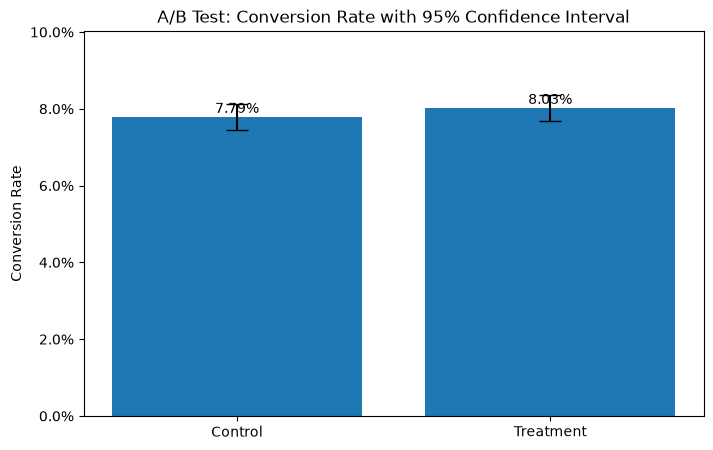

In [19]:
#Step 13 — Add the exact values


plt.figure(figsize=(8, 5))

bars = plt.bar(
    groups,
    conversion_rates,
    yerr=errors,
    capsize=8
)

plt.ylabel("Conversion Rate")
plt.title("A/B Test: Conversion Rate with 95% Confidence Interval")
plt.ylim(0, max(conversion_rates) + 0.02)

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.1%}")
)

# Add values above bars
for bar, rate in zip(bars, conversion_rates):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        f"{rate:.2%}",
        ha="center"
    )

plt.show()

In [20]:
# 14 — Device conversion rates
device_results = (
    df.groupby(["device", "experiment_group"])["purchased"]
      .agg(["count", "sum"])
      .reset_index()
)

device_results["conversion_rate"] = (
    device_results["sum"] / device_results["count"]
)

device_results

,device,experiment_group,count,sum,conversion_rate
0,Desktop,Control,7387,636,0.086097
1,Desktop,Treatment,7469,714,0.095595
2,Mobile,Control,14939,1103,0.073834
3,Mobile,Treatment,15151,1114,0.073526
4,Tablet,Control,2488,195,0.078376
5,Tablet,Treatment,2566,194,0.075604


In [21]:
#15 — Make Control vs Treatment easier to compare
device_comparison = device_results.pivot(
    index="device",
    columns="experiment_group",
    values="conversion_rate"
)

device_comparison["difference"] = (
    device_comparison["Treatment"] -
    device_comparison["Control"]
)

device_comparison["uplift"] = (
    device_comparison["difference"] /
    device_comparison["Control"]
)

device_comparison

experiment_group,Control,Treatment,difference,uplift
device,,,,
Desktop,0.086097,0.095595,0.009498,0.110316
Mobile,0.073834,0.073526,-0.000307,-0.004159
Tablet,0.078376,0.075604,-0.002772,-0.035370


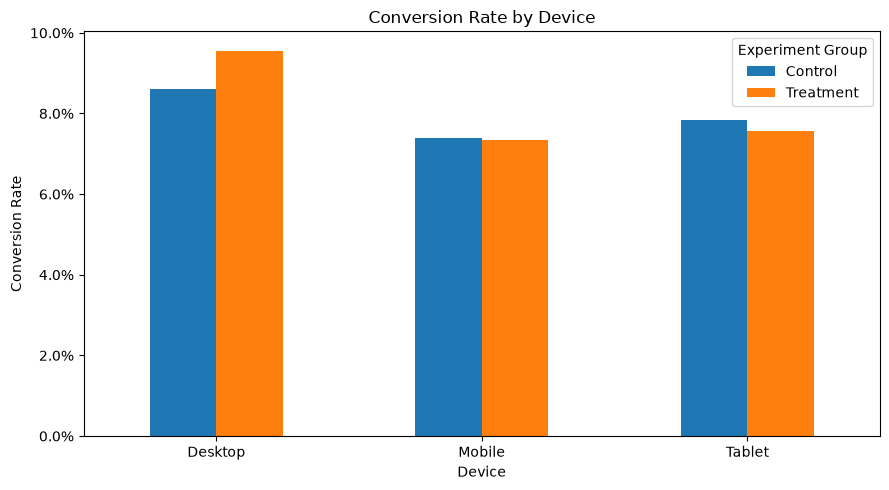

In [22]:
#16 — Visualize device performance

device_comparison[["Control", "Treatment"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Conversion Rate by Device")
plt.xlabel("Device")
plt.ylabel("Conversion Rate")

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.1%}")
)

plt.xticks(rotation=0)
plt.legend(title="Experiment Group")
plt.tight_layout()
plt.show()

In [24]:
#Step 17 — Statistical Test by Device

def ab_test(control_data, treatment_data):
    
    n_control = len(control_data)
    n_treatment = len(treatment_data)
    
    x_control = control_data["purchased"].sum()
    x_treatment = treatment_data["purchased"].sum()
    
    p_control = x_control / n_control
    p_treatment = x_treatment / n_treatment
    
    # Pooled conversion
    p_pooled = (x_control + x_treatment) / (n_control + n_treatment)
    
    # Standard error
    se = np.sqrt(
        p_pooled * (1 - p_pooled) *
        (1/n_control + 1/n_treatment)
    )
    
    # Z-score
    z = (p_treatment - p_control) / se
    
    # Two-sided p-value
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    
    # 95% confidence interval
    difference = p_treatment - p_control
    
    ci_se = np.sqrt(
        (p_control * (1 - p_control) / n_control) +
        (p_treatment * (1 - p_treatment) / n_treatment)
    )
    
    ci_lower = difference - 1.96 * ci_se
    ci_upper = difference + 1.96 * ci_se
    
    return {
        "Control Conversion": p_control,
        "Treatment Conversion": p_treatment,
        "Difference": difference,
        "Uplift": difference / p_control,
        "Z-score": z,
        "P-value": p_value,
        "CI Lower": ci_lower,
        "CI Upper": ci_upper
    }

In [25]:
#Step 18 — Test each device
device_tests = []

for device in df["device"].unique():
    
    control_data = df[
        (df["device"] == device) &
        (df["experiment_group"] == "Control")
    ]
    
    treatment_data = df[
        (df["device"] == device) &
        (df["experiment_group"] == "Treatment")
    ]
    
    result = ab_test(control_data, treatment_data)
    result["Device"] = device
    
    device_tests.append(result)

device_tests_df = pd.DataFrame(device_tests)

device_tests_df

,Control Conversion,Treatment Conversion,Difference,Uplift,Z-score,P-value,CI Lower,CI Upper,Device
0,0.078376,0.075604,-0.002772,-0.035370,-0.369647,0.711645,-0.017475,0.011930,Tablet
1,0.073834,0.073526,-0.000307,-0.004159,-0.101949,0.918797,-0.006211,0.005597,Mobile
2,0.086097,0.095595,0.009498,0.110316,2.013793,0.044031,0.000257,0.018738,Desktop


In [27]:
#Step 19 — Make the results easier to read
display(
    device_tests_df[
        [
            "Device",
            "Control Conversion",
            "Treatment Conversion",
            "Difference",
            "Uplift",
            "P-value",
            "CI Lower",
            "CI Upper"
        ]
    ]
)

,Device,Control Conversion,Treatment Conversion,Difference,Uplift,P-value,CI Lower,CI Upper
0,Tablet,0.078376,0.075604,-0.002772,-0.035370,0.711645,-0.017475,0.011930
1,Mobile,0.073834,0.073526,-0.000307,-0.004159,0.918797,-0.006211,0.005597
2,Desktop,0.086097,0.095595,0.009498,0.110316,0.044031,0.000257,0.018738


In [28]:
percentage_columns = [
    "Control Conversion",
    "Treatment Conversion",
    "Difference",
    "Uplift",
    "CI Lower",
    "CI Upper"
]

device_tests_df[percentage_columns] = (
    device_tests_df[percentage_columns] * 100
).round(2)

device_tests_df["P-value"] = device_tests_df["P-value"].round(4)

device_tests_df

,Control Conversion,Treatment Conversion,Difference,Uplift,Z-score,P-value,CI Lower,CI Upper,Device
0,7.84,7.56,-0.28,-3.54,-0.369647,0.7116,-1.75,1.19,Tablet
1,7.38,7.35,-0.03,-0.42,-0.101949,0.9188,-0.62,0.56,Mobile
2,8.61,9.56,0.95,11.03,2.013793,0.0440,0.03,1.87,Desktop


In [29]:
#Step 20 — User Type Analysis


user_type_results = (
    df.groupby(["user_type", "experiment_group"])["purchased"]
      .agg(["count", "sum"])
      .reset_index()
)

user_type_results["conversion_rate"] = (
    user_type_results["sum"] / user_type_results["count"]
)

user_type_results

,user_type,experiment_group,count,sum,conversion_rate
0,New,Control,14903,990,0.066430
1,New,Treatment,15131,1063,0.070253
2,Returning,Control,9911,944,0.095248
3,Returning,Treatment,10055,959,0.095375


In [30]:
# 21 — Compare Control vs Treatment
user_type_comparison = user_type_results.pivot(
    index="user_type",
    columns="experiment_group",
    values="conversion_rate"
)

user_type_comparison["difference"] = (
    user_type_comparison["Treatment"] -
    user_type_comparison["Control"]
)

user_type_comparison["uplift"] = (
    user_type_comparison["difference"] /
    user_type_comparison["Control"]
)

user_type_comparison

experiment_group,Control,Treatment,difference,uplift
user_type,,,,
New,0.066430,0.070253,0.003824,0.057558
Returning,0.095248,0.095375,0.000128,0.001341


In [31]:
#step 22 — Statistical test for each user type


user_type_tests = []

for user_type in df["user_type"].unique():
    
    control_data = df[
        (df["user_type"] == user_type) &
        (df["experiment_group"] == "Control")
    ]
    
    treatment_data = df[
        (df["user_type"] == user_type) &
        (df["experiment_group"] == "Treatment")
    ]
    
    result = ab_test(control_data, treatment_data)
    result["User Type"] = user_type
    
    user_type_tests.append(result)

user_type_tests_df = pd.DataFrame(user_type_tests)

user_type_tests_df

,Control Conversion,Treatment Conversion,Difference,Uplift,Z-score,P-value,CI Lower,CI Upper,User Type
0,0.066430,0.070253,0.003824,0.057558,1.312857,0.189231,-0.001883,0.009531,New
1,0.095248,0.095375,0.000128,0.001341,0.030731,0.975484,-0.008019,0.008274,Returning


In [32]:
#step 23 — Clean presentation
display(
    user_type_tests_df[
        [
            "User Type",
            "Control Conversion",
            "Treatment Conversion",
            "Difference",
            "Uplift",
            "P-value",
            "CI Lower",
            "CI Upper"
        ]
    ]
)

#Then format it:

percentage_columns = [
    "Control Conversion",
    "Treatment Conversion",
    "Difference",
    "Uplift",
    "CI Lower",
    "CI Upper"
]

user_type_tests_df[percentage_columns] = (
    user_type_tests_df[percentage_columns] * 100
).round(2)

user_type_tests_df["P-value"] = (
    user_type_tests_df["P-value"].round(4)
)

user_type_tests_df

,User Type,Control Conversion,Treatment Conversion,Difference,Uplift,P-value,CI Lower,CI Upper
0,New,0.066430,0.070253,0.003824,0.057558,0.189231,-0.001883,0.009531
1,Returning,0.095248,0.095375,0.000128,0.001341,0.975484,-0.008019,0.008274


,Control Conversion,Treatment Conversion,Difference,Uplift,Z-score,P-value,CI Lower,CI Upper,User Type
0,6.64,7.03,0.38,5.76,1.312857,0.1892,-0.19,0.95,New
1,9.52,9.54,0.01,0.13,0.030731,0.9755,-0.80,0.83,Returning


In [33]:

#Step 24 — Country Analysis

country_results = (
    df.groupby(["country", "experiment_group"])["purchased"]
      .agg(["count", "sum"])
      .reset_index()
)

country_results["conversion_rate"] = (
    country_results["sum"] / country_results["count"]
)

country_results

,country,experiment_group,count,sum,conversion_rate
0,Australia,Control,1978,135,0.068251
1,Australia,Treatment,2057,167,0.081186
2,Canada,Control,2416,198,0.081954
3,Canada,Treatment,2613,210,0.080367
4,India,Control,11230,893,0.079519
5,India,Treatment,11271,878,0.077899
6,UK,Control,2991,239,0.079906
7,UK,Treatment,2999,257,0.085695
8,USA,Control,6199,469,0.075657
9,USA,Treatment,6246,510,0.081652


In [34]:
#25 — Control vs Treatment comparison
country_comparison = country_results.pivot(
    index="country",
    columns="experiment_group",
    values="conversion_rate"
)

country_comparison["difference"] = (
    country_comparison["Treatment"] -
    country_comparison["Control"]
)

country_comparison["uplift"] = (
    country_comparison["difference"] /
    country_comparison["Control"]
)

country_comparison

experiment_group,Control,Treatment,difference,uplift
country,,,,
Australia,0.068251,0.081186,0.012935,0.189528
Canada,0.081954,0.080367,-0.001586,-0.019355
India,0.079519,0.077899,-0.001620,-0.020374
UK,0.079906,0.085695,0.005789,0.072445
USA,0.075657,0.081652,0.005995,0.079237


In [35]:
#Step 26 — Statistical test for each country
country_tests = []

for country in df["country"].unique():
    
    control_data = df[
        (df["country"] == country) &
        (df["experiment_group"] == "Control")
    ]
    
    treatment_data = df[
        (df["country"] == country) &
        (df["experiment_group"] == "Treatment")
    ]
    
    result = ab_test(control_data, treatment_data)
    result["Country"] = country
    
    country_tests.append(result)

country_tests_df = pd.DataFrame(country_tests)

country_tests_df

,Control Conversion,Treatment Conversion,Difference,Uplift,Z-score,P-value,CI Lower,CI Upper,Country
0,0.079519,0.077899,-0.001620,-0.020374,-0.451241,0.651816,-0.008657,0.005417,India
1,0.075657,0.081652,0.005995,0.079237,1.242062,0.214214,-0.003463,0.015453,USA
2,0.081954,0.080367,-0.001586,-0.019355,-0.205841,0.836915,-0.016696,0.013523,Canada
3,0.079906,0.085695,0.005789,0.072445,0.812862,0.416297,-0.008168,0.019746,UK
4,0.068251,0.081186,0.012935,0.189528,1.560992,0.118526,-0.003276,0.029147,Australia


In [36]:
#Step 27 — Display the important results
display(
    country_tests_df[
        [
            "Country",
            "Control Conversion",
            "Treatment Conversion",
            "Difference",
            "Uplift",
            "P-value",
            "CI Lower",
            "CI Upper"
        ]
    ]
)

#Format it:

percentage_columns = [
    "Control Conversion",
    "Treatment Conversion",
    "Difference",
    "Uplift",
    "CI Lower",
    "CI Upper"
]

country_tests_df[percentage_columns] = (
    country_tests_df[percentage_columns] * 100
).round(2)

country_tests_df["P-value"] = (
    country_tests_df["P-value"].round(4)
)

country_tests_df

,Country,Control Conversion,Treatment Conversion,Difference,Uplift,P-value,CI Lower,CI Upper
0,India,0.079519,0.077899,-0.001620,-0.020374,0.651816,-0.008657,0.005417
1,USA,0.075657,0.081652,0.005995,0.079237,0.214214,-0.003463,0.015453
2,Canada,0.081954,0.080367,-0.001586,-0.019355,0.836915,-0.016696,0.013523
3,UK,0.079906,0.085695,0.005789,0.072445,0.416297,-0.008168,0.019746
4,Australia,0.068251,0.081186,0.012935,0.189528,0.118526,-0.003276,0.029147


,Control Conversion,Treatment Conversion,Difference,Uplift,Z-score,P-value,CI Lower,CI Upper,Country
0,7.95,7.79,-0.16,-2.04,-0.451241,0.6518,-0.87,0.54,India
1,7.57,8.17,0.60,7.92,1.242062,0.2142,-0.35,1.55,USA
2,8.20,8.04,-0.16,-1.94,-0.205841,0.8369,-1.67,1.35,Canada
3,7.99,8.57,0.58,7.24,0.812862,0.4163,-0.82,1.97,UK
4,6.83,8.12,1.29,18.95,1.560992,0.1185,-0.33,2.91,Australia


In [39]:
#Final Traffic Source



traffic_results = (
    df.groupby(["traffic_source", "experiment_group"])["purchased"]
      .agg(["count", "sum"])
      .reset_index()
)

traffic_results["conversion_rate"] = (
    traffic_results["sum"] / traffic_results["count"]
)

traffic_results




,traffic_source,experiment_group,count,sum,conversion_rate
0,Direct,Control,3748,309,0.082444
1,Direct,Treatment,3782,322,0.085140
2,Email,Control,2471,231,0.093484
3,Email,Treatment,2528,241,0.095332
4,Organic,Control,7981,575,0.072046
5,Organic,Treatment,8118,606,0.074649
6,Paid Search,Control,6192,473,0.076389
7,Paid Search,Treatment,6255,492,0.078657
8,Social,Control,4422,346,0.078245
9,Social,Treatment,4503,361,0.080169


In [43]:
traffic_comparison = traffic_results.pivot(
    index="traffic_source",
    columns="experiment_group",
    values="conversion_rate"
)

traffic_comparison["difference"] = (
    traffic_comparison["Treatment"] -
    traffic_comparison["Control"]
)

traffic_comparison["uplift"] = (
    traffic_comparison["difference"] /
    traffic_comparison["Control"]
)

traffic_comparison

experiment_group,Control,Treatment,difference,uplift
traffic_source,,,,
Direct,0.082444,0.085140,0.002696,0.032703
Email,0.093484,0.095332,0.001848,0.019766
Organic,0.072046,0.074649,0.002603,0.036127
Paid Search,0.076389,0.078657,0.002268,0.029693
Social,0.078245,0.080169,0.001924,0.024585


In [45]:
#Step 28 — Statistical test for Traffic Source

traffic_tests = []

for source in df["traffic_source"].unique():
    
    control_data = df[
        (df["traffic_source"] == source) &
        (df["experiment_group"] == "Control")
    ]
    
    treatment_data = df[
        (df["traffic_source"] == source) &
        (df["experiment_group"] == "Treatment")
    ]
    
    result = ab_test(control_data, treatment_data)
    result["Traffic Source"] = source
    
    traffic_tests.append(result)

traffic_tests_df = pd.DataFrame(traffic_tests)

traffic_tests_df


,Traffic Source,Control Conversion,Treatment Conversion,Difference,Uplift,P-value,CI Lower,CI Upper
0,Organic,0.072046,0.074649,0.002603,0.036127,0.526531,-0.005451,0.010657
1,Email,0.093484,0.095332,0.001848,0.019766,0.823234,-0.014364,0.018059
2,Paid Search,0.076389,0.078657,0.002268,0.029693,0.636130,-0.007128,0.011664
3,Social,0.078245,0.080169,0.001924,0.024585,0.736546,-0.009282,0.013129
4,Direct,0.082444,0.085140,0.002696,0.032703,0.672894,-0.009820,0.015212


In [47]:
#Step 29 — Create one final Python summary


python_summary = pd.DataFrame({
    "Metric": [
        "Control Users",
        "Treatment Users",
        "Control Conversion",
        "Treatment Conversion",
        "Absolute Difference",
        "Relative Uplift",
        "Z-score",
        "P-value",
        "95% CI Lower",
        "95% CI Upper",
        "Statistical Result"
    ],
    
    "Value": [
        n_control,
        n_treatment,
        p_control,
        p_treatment,
        difference,
        relative_uplift,
        z_score,
        p_value,
        ci_lower,
        ci_upper,
        result
    ]
})

python_summary

,Metric,Value
0,Control Users,24814
1,Treatment Users,25186
2,Control Conversion,0.07794
3,Treatment Conversion,0.080283
4,Absolute Difference,0.002343
5,Relative Uplift,0.030059
6,Z-score,0.970371
7,P-value,0.331861
8,95% CI Lower,-0.002389
9,95% CI Upper,0.007074


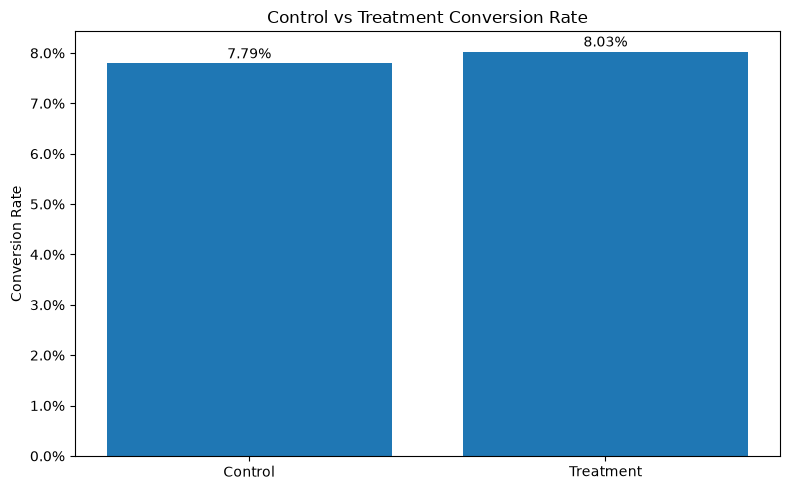

In [48]:
#Step 30 — Final Python visualization


plt.figure(figsize=(8, 5))

bars = plt.bar(
    ["Control", "Treatment"],
    [p_control, p_treatment]
)

plt.ylabel("Conversion Rate")
plt.title("Control vs Treatment Conversion Rate")

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.1%}")
)

for bar, value in zip(bars, [p_control, p_treatment]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{value:.2%}",
        ha="center"
    )

plt.tight_layout()
plt.show()